In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
import os
#import matplotlib.dates as mdates
#from statsmodels.tsa.stattools import acf
#from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display, Markdown
import datetime as dt

In [ ]:
files = {
         'PE': rstr((NB_DIR / '../../../pernambuco/dlnm/data/dengue_pe_2015_2024.csv').resolve()),
         'GO': rstr((NB_DIR / '../../../goias/dlnm/data/dengue_goias_consolidado.csv').resolve()),
         'RJ': rstr((NB_DIR / '../../../rio_de_janeiro/dlnm/data/dengue_rio_de_janeiro_consolidado.csv').resolve()),
         'RS': rstr((NB_DIR / '../../../rio_grande_do_sul/dlnm/data/dengue_rio_grande_do_sul_consolidado.csv').resolve())
        }

state_names = {
               'PE': 'Pernambuco',
               'GO': 'Goiás',
               'RJ': 'Rio de Janeiro',
               'RS': 'Rio Grande do Sul'
               }

all_data = []


for state_abbr, file_path in files.items():
    if not os.path.exists(file_path):
        print(f"Error: File not found for {state_abbr}: {file_path}")
        continue

    try:
        df = pd.read_csv(file_path)

        df['date'] = pd.to_datetime(df['date'])

        df = df[(df['date'] >= '2017-01-01') & (df['date'] <= '2024-12-31')]

        daily_agg = df.groupby('date')['casos'].sum().reset_index()

        daily_agg['state'] = state_names[state_abbr]

        daily_agg['uf'] = state_abbr

        all_data.append(daily_agg)

    except Exception as e:
        print(f"Error processing {state_abbr}: {e}")

if not all_data:
    print("No data loaded. Exiting.")
    exit()


In [ ]:
combined_df = pd.concat(all_data, ignore_index=True)
combined_df = combined_df.sort_values(by=['state', 'date'])
combined_df = combined_df.drop(columns=['uf'])
combined_df = combined_df.pivot(index='date', columns=['state'], values='casos')

In [ ]:
populacoes = {
              'Goiás': 7056495,
              'Pernambuco': 9058931,
              'Rio Grande do Sul': 10882965,
              'Rio de Janeiro': 16054524
             }

incidence_df = pd.DataFrame()
for estado in populacoes.keys():
    incidence_df[f'{estado}'] = (combined_df[estado]/populacoes[estado])*100000

In [ ]:
indexP_df = pd.read_csv(str((NB_DIR / '../../data/indexP_todos_estados.csv').resolve()))
#
indexP_df = indexP_df.set_index('date')
indexP_df.index = pd.to_datetime(indexP_df.index)
indexP_df = indexP_df[list(incidence_df.columns)]

tau = {'Goiás':4.11,'Pernambuco':5.48,
         'Rio de Janeiro':8.59,
         'Rio Grande do Sul': 8.01}
k = 1
processing_df = pd.DataFrame({
    estado: indexP_df[estado].shift(int(tau[estado]))/(incidence_df[estado] + k)
    for estado in populacoes.keys()
})
processing_df = processing_df.fillna(0)
processing_df = processing_df.drop(processing_df.index[-1])

In [ ]:
processing_df.tail()

,Goiás,Pernambuco,Rio Grande do Sul,Rio de Janeiro
date,,,,
2024-05-05,0.009698,0.094970,0.023745,0.039268
2024-05-12,0.012116,0.102475,0.023763,0.051023
2024-05-19,0.018543,0.119876,0.067509,0.066582
2024-05-26,0.034391,0.198603,0.086561,0.152008
2024-06-02,0.145153,0.836783,0.383518,0.564275


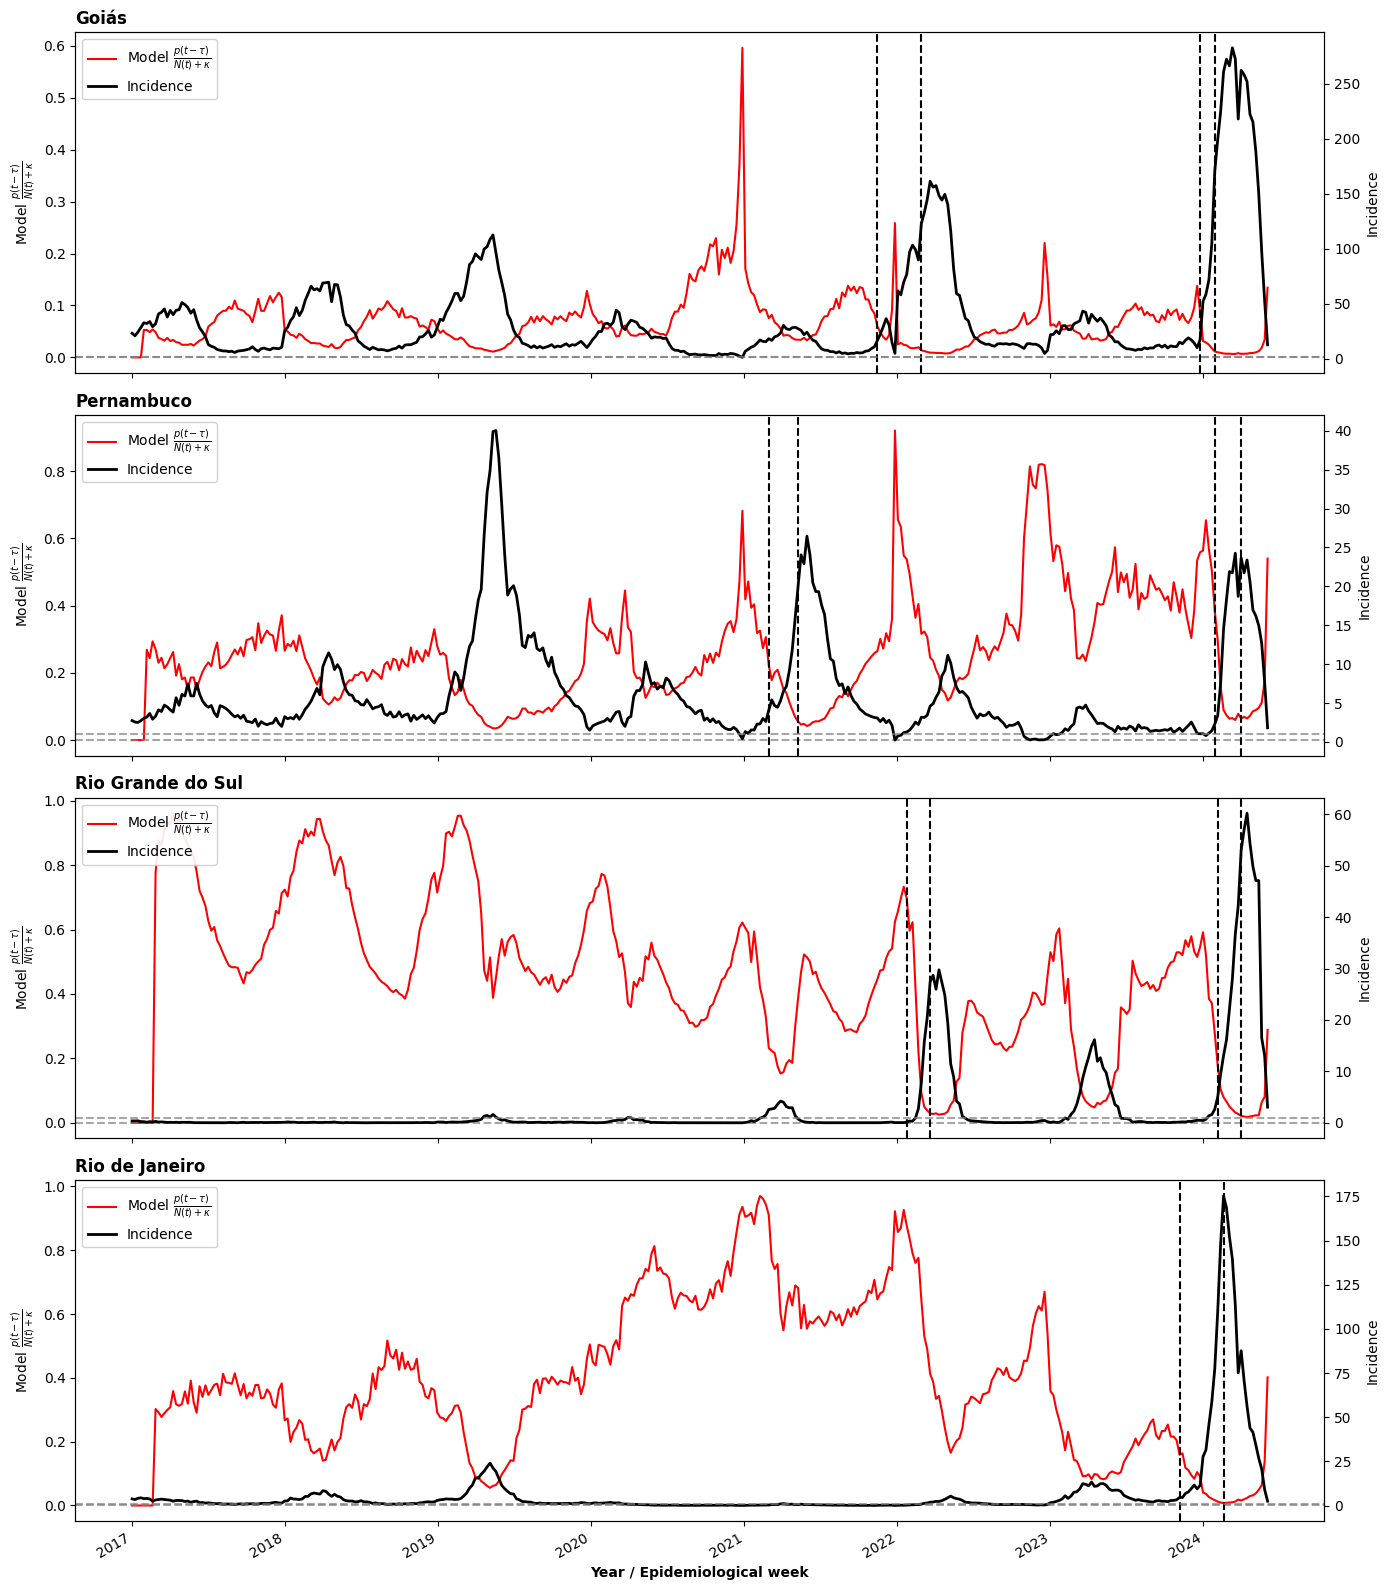

In [ ]:
plot_start_date = incidence_df.index.min()
plot_end_date = incidence_df.index.max()
data_plot = [
    (processing_df['Goiás'], 'red',
     'Goiás',
     incidence_df['Goiás'], 'black',
     ['2021-11-14','2022-02-27',
      '2023-12-24','2024-01-28']),
    (processing_df['Pernambuco'], 'red',
     'Pernambuco',
     incidence_df['Pernambuco'], 'black',
      ['2021-02-28','2021-05-09',
       '2024-01-28','2024-03-31']),
    (processing_df['Rio Grande do Sul'], 'red',
     'Rio Grande do Sul',
     incidence_df['Rio Grande do Sul'], 'black',
     ['2022-01-23','2022-03-20',
      '2024-02-04','2024-03-31']),
    (processing_df['Rio de Janeiro'], 'red',
     'Rio de Janeiro',
     incidence_df['Rio de Janeiro'], 'black',
     ['2023-11-05','2024-02-18'])
]

fig, axs = plt.subplots(nrows=len(data_plot), ncols=1, figsize=(14, len(data_plot) * 4), sharex=True)

if len(data_plot) == 1:
    axs = [axs]

for idx, (process,color_line,title,idxP, color_idxP,days) in enumerate(data_plot):
    ax = axs[idx]

    line1 = ax.plot(processing_df.index,process, color=color_line, label= r'$B_{p}$')
    #line2 = ax.plot(st.index, st, color=color_st, label='second derivative')

    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel(r'$B_{p}$', color='black')
    ax.tick_params(axis='y', labelcolor='black')
    #ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

    ax_twin = ax.twinx()
    line2 = ax_twin.plot(processing_df.index, idxP, color=color_idxP,
                         linestyle='-', linewidth=2, label='Incidence')

    ax_twin.set_ylabel('Incidence', color=color_idxP)
    ax_twin.tick_params(axis='y', labelcolor=color_idxP)
    ax_twin.axhline(y=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)


    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    for day in days:
        ax.axvline(x=pd.to_datetime(day), color='black', linestyle='--')

axs[-1].set_xlabel('Year / Epidemiological week', fontweight='bold')

fig.autofmt_xdate()

fig.tight_layout()
plt.show()

In [ ]:
sorotipo_df = pd.read_csv(str((NB_DIR / '../../data/df_sorotipo.csv').resolve()))
sorotipo_df['Periodo'] = pd.to_datetime(sorotipo_df['Periodo'])
sorotipo_df = sorotipo_df[sorotipo_df['Estado'] == 'Rio de Janeiro'].copy()

start_point = '2017-01'
end_point = '2024-06'
sorotipo_df = sorotipo_df[(sorotipo_df['Periodo'] >= start_point) & (sorotipo_df['Periodo'] <= end_point)].copy()
sorotipo_df.loc[sorotipo_df['Sorotipo'] == 'Sem informacao', 'Sorotipo'] = 0
sorotipo_df['Sorotipo'] = sorotipo_df['Sorotipo'].astype(int)


sorotipo_df = sorotipo_df.pivot_table(
    index='Periodo',
    columns='Sorotipo',
    values='Casos',
    aggfunc='sum'
).fillna(0)


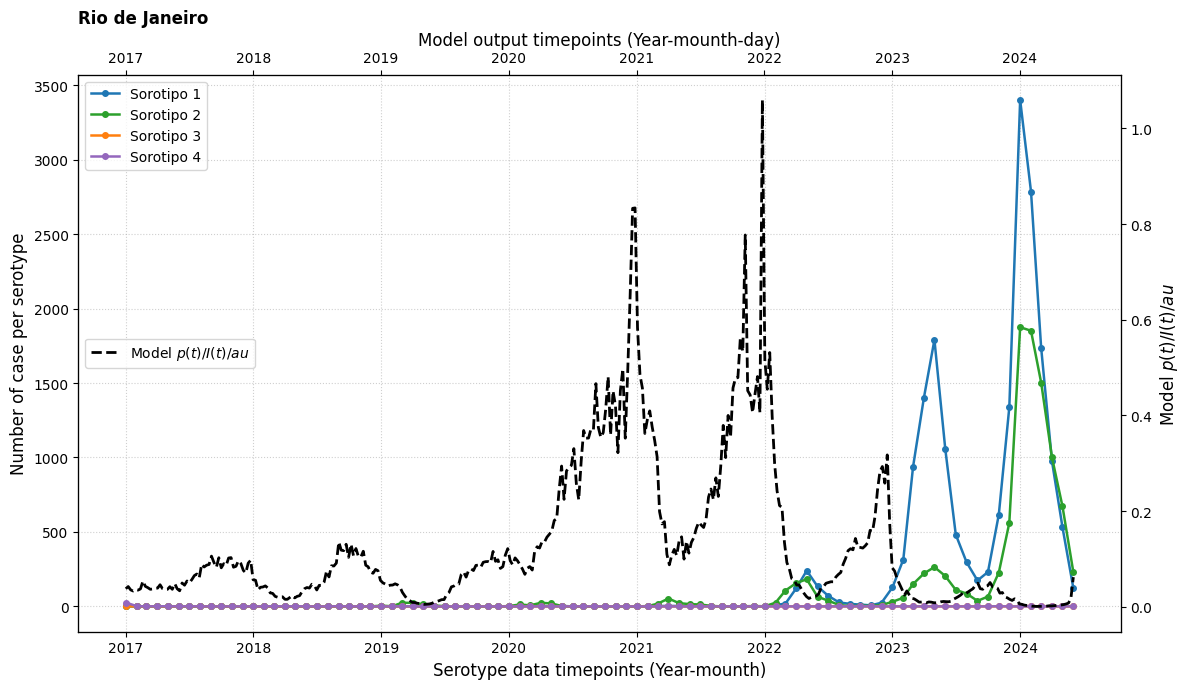

In [ ]:
processing_df.index = pd.to_datetime(processing_df.index)
fig, ax1 = plt.subplots(figsize=(12,7))
cores_sorotipos = {
    1: '#1f77b4',  # Azul
    2: '#2ca02c',  # Verde
    3: '#ff7f0e',  # Laranja
    4: '#9467bd'   # Roxo
}

for sorotipo, cor in cores_sorotipos.items():
    if sorotipo in sorotipo_df.columns:
        ax1.plot(sorotipo_df.index,sorotipo_df[sorotipo],
                 color=cor, marker='o', markersize=4, linewidth=1.8, label=f'Sorotipo {sorotipo}')

ax1.set_xlabel('Serotype data timepoints (Year-mounth)', fontsize=12)
ax1.set_ylabel('Number of case per serotype', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax3 = ax2.twiny()

cor_barreira = '#000000'
ax3.plot(processing_df.index, processing_df['Rio de Janeiro'],
         color=cor_barreira, linestyle='--', linewidth=2, label='Model $p(t)/I(t)/ \tau$')

ax2.set_ylabel('Model $p(t)/I(t)/\tau$', color=cor_barreira, fontsize=12)
ax3.set_xlabel('Model output timepoints (Year-mounth-day)', color=cor_barreira, fontsize=12)


ax2.tick_params(axis='y', labelcolor=cor_barreira)
ax3.legend(loc='center left')
ax3.tick_params(axis='x', labelcolor=cor_barreira)

plt.title("Rio de Janeiro", fontsize=12, fontweight='bold',loc='left')
#plt.title(fr"Goiás: Dengue sorotype dynamic vs. Model $p(t)/I(t)/\tau$", fontsize=14, pad=25)
fig.tight_layout()

plt.show()

In [ ]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [ ]:
deriv_incidence_df = pd.DataFrame()
for estado in state_names.values():
    deriv_incidence_df[f'{estado}_dt'] = incidence_df[estado].diff().fillna(0)
    deriv_incidence_df[f'{estado}_st'] = deriv_incidence_df[f'{estado}_dt'].diff().fillna(0)

In [ ]:
indexP_df = pd.read_csv(str((NB_DIR / '../../data/indexP_todos_estados.csv').resolve()))
indexP_df = indexP_df.set_index('date')

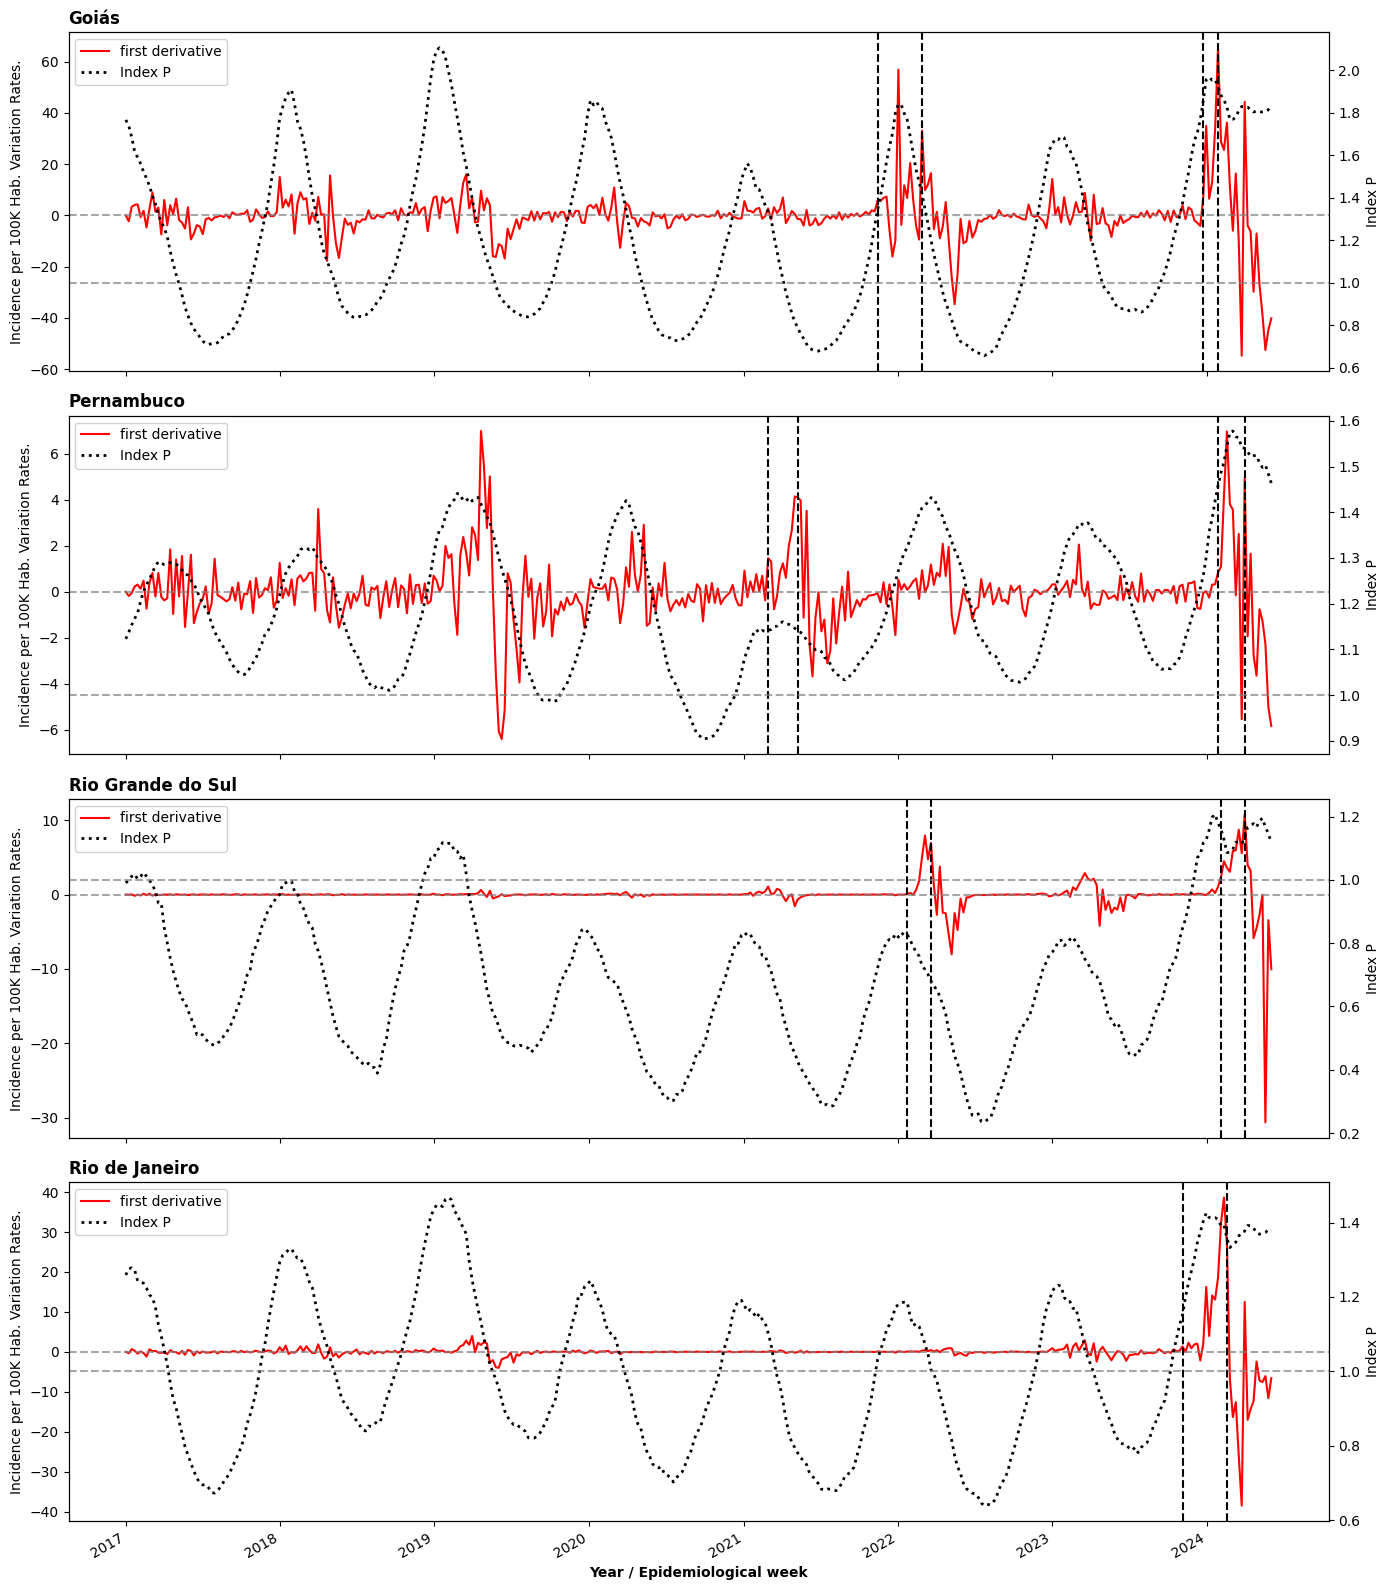

In [ ]:
indexP_df.index = pd.to_datetime(indexP_df.index)
plot_start_date = deriv_incidence_df.index.min()
plot_end_date = deriv_incidence_df.index.max()

data_plot = [
    (deriv_incidence_df['Goiás_dt'], 'red',
     deriv_incidence_df['Goiás_st'], 'green',
     'Goiás',
     indexP_df['Goiás'].loc[plot_start_date:plot_end_date], 'black',
     ['2021-11-14','2022-02-27',
      '2023-12-24','2024-01-28']),
    (deriv_incidence_df['Pernambuco_dt'], 'red',
     deriv_incidence_df['Pernambuco_st'], 'green',
     'Pernambuco',
     indexP_df['Pernambuco'].loc[plot_start_date:plot_end_date], 'black',
      ['2021-02-28','2021-05-09',
       '2024-01-28','2024-03-31']),
    (deriv_incidence_df['Rio Grande do Sul_dt'], 'red',
     deriv_incidence_df['Rio Grande do Sul_st'], 'green',
     'Rio Grande do Sul',
     indexP_df['Rio Grande do Sul'].loc[plot_start_date:plot_end_date], 'black',
     ['2022-01-23','2022-03-20',
      '2024-02-04','2024-03-31']),
    (deriv_incidence_df['Rio de Janeiro_dt'], 'red',
     deriv_incidence_df['Rio de Janeiro_st'], 'green',
     'Rio de Janeiro',
     indexP_df['Rio de Janeiro'].loc[plot_start_date:plot_end_date], 'black',
     ['2023-11-05','2024-02-18'])
]

fig, axs = plt.subplots(nrows=len(data_plot), ncols=1, figsize=(14, len(data_plot) * 4), sharex=True)

if len(data_plot) == 1:
    axs = [axs]

for idx, (dt, color_dt, st, color_st, title, idxP, color_idxP,days) in enumerate(data_plot):
    ax = axs[idx]

    line1 = ax.plot(dt.index, dt, color=color_dt, label='first derivative')
    #line2 = ax.plot(st.index, st, color=color_st, label='second derivative')

    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Incidence per 100K Hab. Variation Rates.', color='black')
    ax.tick_params(axis='y', labelcolor='black')
    #ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

    ax_twin = ax.twinx()
    line3 = ax_twin.plot(idxP.index, idxP, color=color_idxP, linestyle=':', linewidth=2, label='Index P')

    ax_twin.set_ylabel('Index P', color=color_idxP)
    ax_twin.tick_params(axis='y', labelcolor=color_idxP)
    ax_twin.axhline(y=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)


    lines = line1 + line3
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    for day in days:
        ax.axvline(x=pd.to_datetime(day), color='black', linestyle='--')

axs[-1].set_xlabel('Year / Epidemiological week', fontweight='bold')

fig.autofmt_xdate()

fig.tight_layout()
plt.show()

Período de Surto por estados

Goiás: 2021-07-04 / 2022-07-03 ; 2023-06-04 / 2024-06-02
Rio Grande do Sul: 2021-07-04 / 2022-07-03 ; 2023-06-04 / 2024-06-02
Pernambuco: 2021-01-03 / 2022-01-02 ; 2023-06-04 / 2024-06-02
Rio de Janeiro: 2023-06-04 / 2024-06-02

In [ ]:
season_start = '2023-06-04'
season_end = '2024-06-02'
place_name = 'Goiás'
season_df = pd.DataFrame()
season_df = combined_df[(combined_df.index >= season_start) &
                        (combined_df.index <= season_end)].copy()

In [ ]:
derivative_df = pd.DataFrame()
derivative_df[place_name+'_dt'] = season_df[place_name].diff().fillna(0)
derivative_df[place_name+'_st'] = derivative_df[place_name+'_dt'].diff().fillna(0)
derivative_df[place_name+'_mu_t'] = derivative_df[place_name+'_dt'].expanding().mean().fillna(0)
derivative_df[place_name+'_sigma_t'] = derivative_df[place_name+'_dt'].expanding().std().fillna(0)
dt_kvalues_df = pd.DataFrame()

k_values = np.arange(0,3,0.125)

for loop in k_values:
    col_name = f'k_{loop}'

    dt_kvalues_df[col_name] = derivative_df[place_name+'_dt'] > (derivative_df[place_name+'_mu_t'] +
                                                     loop*derivative_df[place_name+'_sigma_t'])

In [ ]:
dt_kvalues_df

In [ ]:
# sufixes = ['_dt', '_mu_t', '_sigma_t']
# colsNames_dt = [f'{col}{suf}' for suf in sufixes for col in season_df.columns]
# derivative_df = pd.DataFrame(columns=colsNames_dt,index=season_df.index)
# aux_lst = list(range(len(colsNames_dt)))
# n = 4
# chunks = [aux_lst[i:i + n] for i in range(0, len(aux_lst), n)]

# for chunks_id, idx in enumerate(chunks):

#     targets_cols = derivative_df.columns[idx]
#     prime_cols = season_df.columns

#     match chunks_id:
#         case 0:
#             derivative_df[targets_cols] = season_df[prime_cols].diff().fillna(0).values
#         case 1:
#             derivative_df[targets_cols] = season_df[prime_cols].expanding().mean().values
#         case 2:
#             derivative_df[targets_cols] = season_df[prime_cols].expanding().std().values


# dt_kvalues_df = pd.DataFrame()
# k_values = [
#             0.25,0.5,0.75,1,
#             1.25,1.5,1.75,2,
#             2.25,2.5,2.75,3,
#             3.25,3.5,3.75,4
#            ]

# for loop in k_values:
#     col_name = f'k_{loop}'

#     dt_kvalues_df[col_name] = derivative_df['Goiás_dt'] > (derivative_df['Goiás_mu_t'] +
#                                                      loop*derivative_df['Goiás_sigma_t'])

In [ ]:
tests_df = pd.read_csv(str((NB_DIR / '../../data/Lab_Denv.csv').resolve()))
tests_df['datas'] = pd.to_datetime(tests_df['date'])
tests_df = tests_df.set_index('datas')
tests_df = tests_df.drop(columns = ['date'])

# Convert relevant columns to numeric, handling potential errors
tests_df['pos_pcr_' + place_name] = pd.to_numeric(tests_df['pos_pcr_' + place_name], errors='coerce')
tests_df['neg_pcr_' + place_name] = pd.to_numeric(tests_df['neg_pcr_' + place_name], errors='coerce')
tests_df['inc_pcr_' + place_name] = pd.to_numeric(tests_df['inc_pcr_' + place_name], errors='coerce')

tests_season_df = tests_df[(tests_df.index >= season_start) & (tests_df.index <= season_end)].copy()
tests_season_df['pos_rates'] = 0.0

for idx in tests_season_df.index:

  pcr_pos = tests_season_df.loc[idx,'pos_pcr_'+place_name] #+ tests_season_df.loc[idx,'pos_eli_'+place_name]
  pcr_neg = tests_season_df.loc[idx,'neg_pcr_'+place_name] #+ tests_season_df.loc[idx,'neg_eli_'+place_name]
  pcr_inc = tests_season_df.loc[idx,'inc_pcr_'+place_name]
  #tests_season_df.loc[idx,'pos_rates'] = pcr_pos/(pcr_pos + pcr_neg + pcr_inc)
  first_gate = (pcr_pos + pcr_neg + pcr_inc ) >= 10
  #second_gate = (pcr_pos >= 5 & pcr_neg >= 5 & pcr_inc >=5)
  if first_gate:       #and second_gate:
    tests_season_df.loc[idx,'pos_rates'] = pcr_pos/(pcr_pos + pcr_neg + pcr_inc)
  else:
    pass

In [ ]:
df_filtered = tests_season_df.loc[:, tests_season_df.columns.str.endswith('_'+place_name)].copy()
df_filtered['rates'] = tests_season_df['pos_rates']
df_filtered

In [ ]:
limiar_epi = tests_season_df['pos_rates'].max()*0.2
tests_season_df['outbreak'] = tests_season_df['pos_rates'] >= limiar_epi

In [ ]:
alerts = tests_season_df['outbreak'].index[tests_season_df['outbreak'] == True]
display(Markdown(f"### {place_name} lab test: the first alert data is: {alerts[0]} and the last alert date is {alerts[-1]}"))

### Goiás lab test: the first alert data is: 2023-06-04 00:00:00 and the last alert date is 2024-06-02 00:00:00

In [ ]:
t_alert_dt = dt_kvalues_df.idxmax()[dt_kvalues_df.any()]
t_alert_dt = t_alert_dt.to_frame().T
display(Markdown(f"### {place_name}: alert triggered through temporal derivative according to k value"))
print(t_alert_dt.T)

### Goiás: alert triggered through temporal derivative according to k value

                 0
k_0.0   2023-07-09
k_0.125 2023-07-09
k_0.25  2023-07-09
k_0.375 2023-07-09
k_0.5   2023-07-09
k_0.625 2023-07-09
k_0.75  2023-07-09
k_0.875 2023-07-30
k_1.0   2023-07-30
k_1.125 2023-07-30
k_1.25  2023-07-30
k_1.375 2023-07-30
k_1.5   2023-08-13
k_1.625 2023-08-13
k_1.75  2023-11-05
k_1.875 2023-11-05
k_2.0   2023-11-05
k_2.125 2023-11-05
k_2.25  2023-11-05
k_2.375 2023-11-05
k_2.5   2023-12-24
k_2.625 2023-12-24
k_2.75  2023-12-24
k_2.875 2023-12-24


In [ ]:
bigN = (tests_season_df['outbreak']==True).sum()
bigN_line = (tests_season_df['outbreak'] == False).sum()

colsNames_k = [f'k_{k}' for k in k_values]
fpr_tpr = pd.DataFrame(columns=colsNames_k, index=['FPR', 'TPR'])
for i in colsNames_k:

    n_true  = (tests_season_df['outbreak']==True) & (dt_kvalues_df[i]==True)
    fpr_tpr.at['TPR',i] = n_true.sum()/bigN
    n_line = (tests_season_df['outbreak']==False) & (dt_kvalues_df[i]==True)
    fpr_tpr.at['FPR',i] = n_line.sum()/bigN_line

In [ ]:
print(fpr_tpr.T)

              FPR   TPR
k_0.0    0.607143  0.44
k_0.125  0.607143  0.44
k_0.25        0.5  0.44
k_0.375  0.464286   0.4
k_0.5    0.428571   0.4
k_0.625  0.428571   0.4
k_0.75   0.392857  0.36
k_0.875  0.357143  0.32
k_1.0    0.321429  0.32
k_1.125  0.321429  0.32
k_1.25   0.285714  0.32
k_1.375  0.285714  0.32
k_1.5    0.178571  0.28
k_1.625  0.178571  0.28
k_1.75   0.107143   0.2
k_1.875  0.071429   0.2
k_2.0    0.071429   0.2
k_2.125  0.071429  0.16
k_2.25   0.071429  0.12
k_2.375  0.071429  0.12
k_2.5    0.035714  0.12
k_2.625  0.035714  0.12
k_2.75   0.035714  0.12
k_2.875  0.035714  0.12


In [ ]:
k_alert = dt_kvalues_df.index[dt_kvalues_df['k_2.0'] == True]
display(Markdown(f"### According the best k value, the outbreak spark at {k_alert[0]} and start to damp down at: {k_alert[-1]} "))

### According the best k value, the outbreak spark at 2023-11-05 00:00:00 and start to damp down at: 2024-03-31 00:00:00 

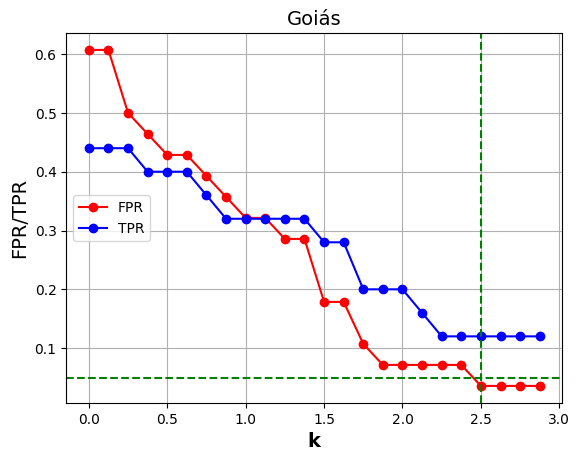

In [ ]:
plt.plot(k_values,fpr_tpr.loc['FPR'],'-or',label='FPR')
plt.plot(k_values,fpr_tpr.loc['TPR'],'-ob',label='TPR')
plt.axvline(x=2.5, color='green', linestyle='--', linewidth=1.5)
plt.axhline(y=0.05, color='green', linestyle='--', linewidth=1.5)
plt.title(f'{place_name}',
          fontsize=14)
plt.xlabel('k',
           fontweight='bold',
           fontsize=14)
plt.ylabel('FPR/TPR',fontsize=14)
plt.legend()
plt.grid()
plt.show()


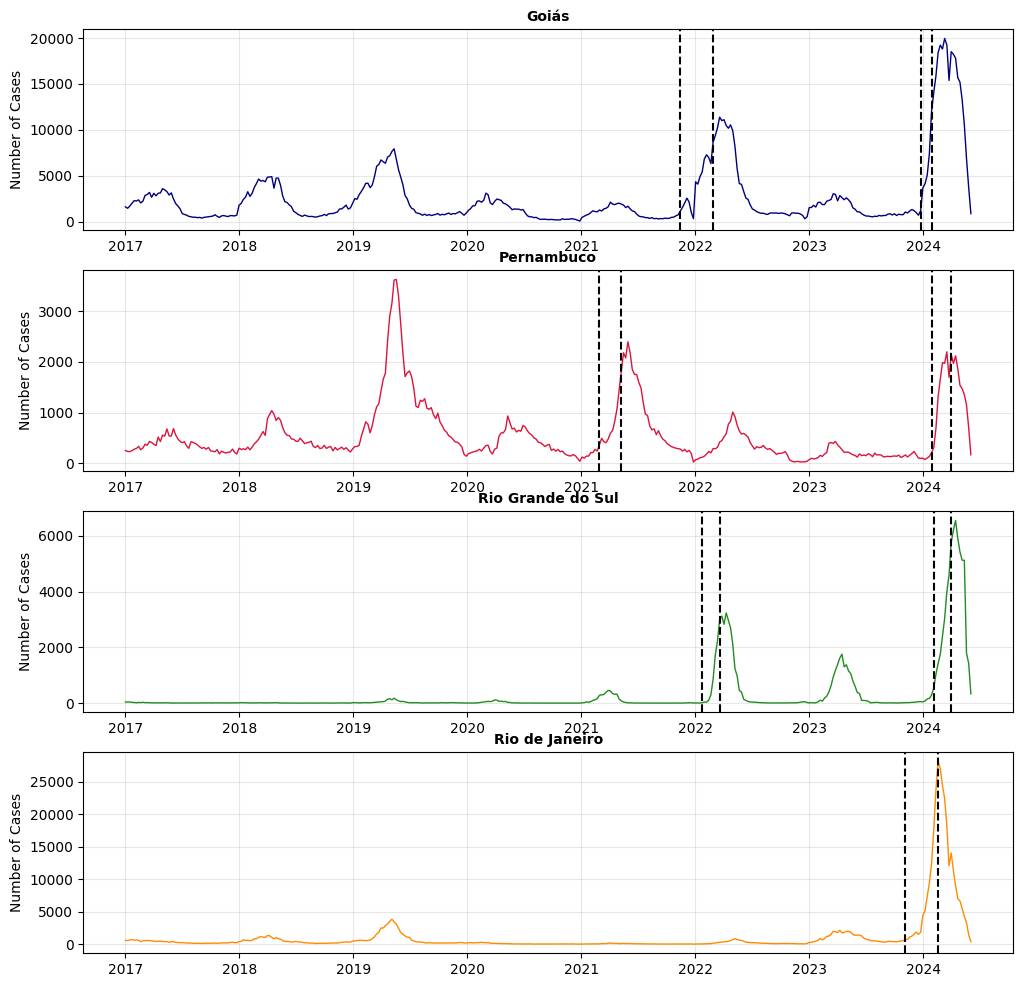

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(12,12), sharex=False)
datasets = [
            (combined_df['Goiás'],'Goiás', 'navy',['2021-11-14','2022-02-27',
                                                    '2023-12-24','2024-01-28']),
            (combined_df['Pernambuco'],'Pernambuco', 'crimson',['2021-02-28','2021-05-09',
                                                                 '2024-01-28','2024-03-31']),
            (combined_df['Rio Grande do Sul'],'Rio Grande do Sul','forestgreen',
                                                                  ['2022-01-23','2022-03-20',
                                                                   '2024-02-04','2024-03-31']),
            (combined_df['Rio de Janeiro'], 'Rio de Janeiro', 'darkorange',['2023-11-05','2024-02-18'])
            ]

for i, (series, title, color,days) in enumerate(datasets):


    axs[i].plot(series, color=color, linewidth=1)
    axs[i].set_title(title, fontsize=10, fontweight='bold')
    axs[i].set_ylabel('Number of Cases')
    for day in days:
        axs[i].axvline(x=pd.to_datetime(day), color='black', linestyle='--')

    axs[i].grid(True, alpha=0.3)

In [ ]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


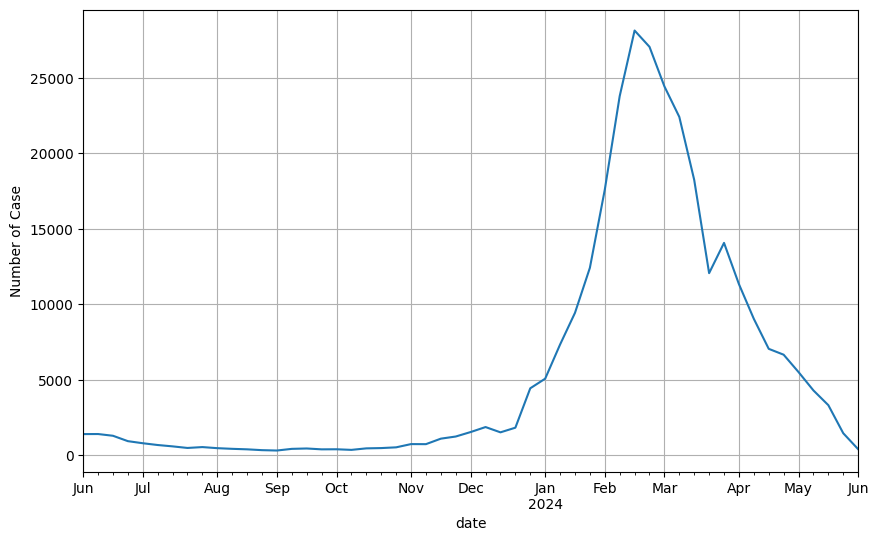

In [ ]:
ax = season_df[place_name].plot(figsize=(10, 6))
ax.set_ylabel('Number of Case')
# ax.axvline(x='2024-01-14', color='black', linestyle='--')
# ax.axvline(x='2023-12-31', color='green', linestyle='--')
#ax.axvline(x='2024-01-28', color='red', linestyle='--')
plt.grid()
plt.show()

In [ ]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y
